# Eksperimen E3: Evaluasi Penolakan Kelas Terbuka (Open-Set Rejection) & Kalibrasi Ambang Batas (τ*)

**Topik Penelitian:** Ketahanan Representasi Audio terhadap Derau dan Pergeseran Domain untuk Pencarian Kemiripan Bioakustik

### Pertanyaan Penelitian Terkait (Sub-RQ2):
> *Apakah ambang batas kemiripan (similarity threshold τ) yang dikalibrasi secara objektif pada subset terpisah mampu menolak sinyal audio asing (unknown/background noise) secara andal tanpa menyebabkan peningkatan False Positive Rate yang berlebihan ketika tingkat derau lingkungan memburuk (Clean s.d. -5 dB SNR)?*

### Hipotesis (H4):
> *Ambang batas penolakan τ* yang dikalibrasi pada kondisi bersih akan mengalami inflasi False Positive yang signifikan pada representasi generik/MFCC saat derau meningkat, sementara representasi bioakustik (BirdNET) mempertahankan selektivitas penolakan yang lebih stabil.*

---

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

NOTEBOOK_DIR = Path(os.getcwd())
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

MANIFEST_DIR = REPO_ROOT / 'data/manifests'
PROCESSED_DIR = REPO_ROOT / 'results/processed'
RAW_DIR = REPO_ROOT / 'results/raw'
FIGURES_DIR = REPO_ROOT / 'results/figures'
PAPER_FIG_DIR = REPO_ROOT / 'paper/figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PAPER_FIG_DIR.mkdir(parents=True, exist_ok=True)

df_split = pd.read_csv(MANIFEST_DIR / 'dataset_split.csv')
df_unk = pd.read_csv(MANIFEST_DIR / 'unknown_open_set_manifest.csv')

print(f'[+] Dataset Split: {len(df_split):,} baris')
print(f'    - Gallery: {len(df_split[df_split["split_role"] == "gallery"]):,}')
print(f'    - Calibration Known: {len(df_split[df_split["split_role"] == "calibration"]):,}')
print(f'    - Query Clean Known: {len(df_split[df_split["split_role"] == "query_clean"]):,}')
print(f'[+] Unknown Open-Set Manifest: {len(df_unk):,} baris')
print(f'    - Unknown Calibration: {len(df_unk[df_unk["split_role"] == "unknown_calibration"]):,}')
print(f'    - Unknown Test: {len(df_unk[df_unk["split_role"] == "unknown_test"]):,}')

[+] Dataset Split: 4,351 baris
    - Gallery: 3,653
    - Calibration Known: 498
    - Query Clean Known: 200
[+] Unknown Open-Set Manifest: 698 baris
    - Unknown Calibration: 498
    - Unknown Test: 200


In [2]:
with open(REPO_ROOT / 'configs/thresholds.yaml', 'r') as f:
    thresholds_cfg = yaml.safe_load(f)

df_calib = pd.read_csv(PROCESSED_DIR / 'calibration_summary_table.csv')
print('=== HASIL KALIBRASI AMBANG BATAS OBJEKTIF (YOUDEN J) PADA SUBSET TERPISAH ===')
display(df_calib[['representation', 'frozen_tau', 'calib_youden_j', 'calib_auroc', 'calib_f1', 'calib_recall', 'calib_fpr']])

=== HASIL KALIBRASI AMBANG BATAS OBJEKTIF (YOUDEN J) PADA SUBSET TERPISAH ===


,representation,frozen_tau,calib_youden_j,calib_auroc,calib_f1,calib_recall,calib_fpr
0,R0,0.995346,0.062249,0.515006,0.460116,0.399598,0.337349
1,R1,0.911720,0.279116,0.674110,0.674524,0.746988,0.467871
2,R2,0.712817,0.477912,0.814749,0.735772,0.726908,0.248996
3,R3,0.509013,0.078313,0.533116,0.620347,0.753012,0.674699


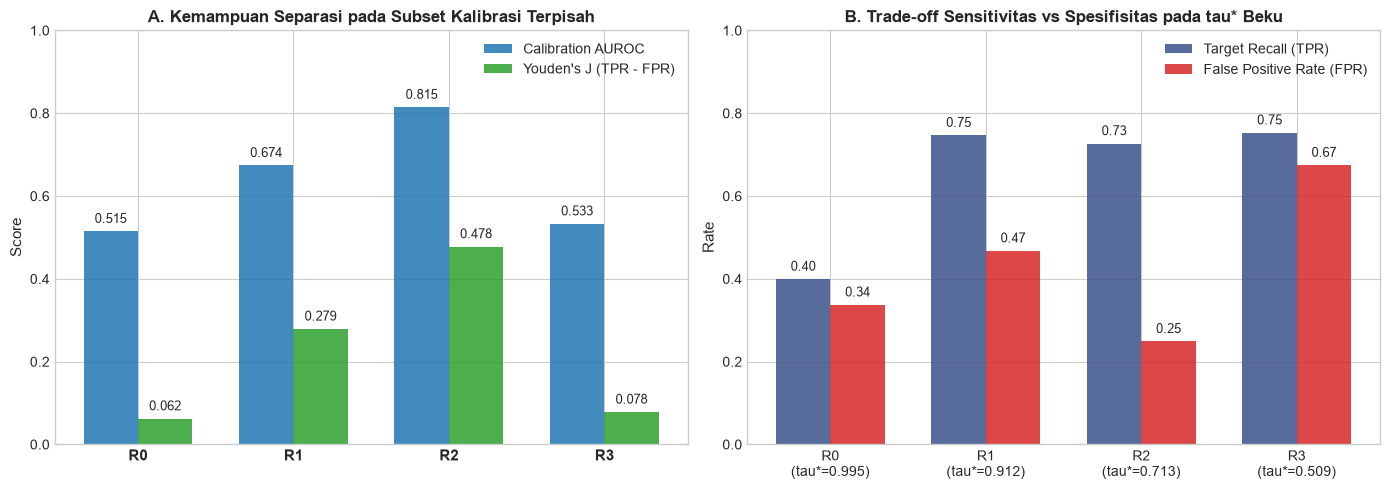

In [3]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Youden's J & AUROC per Representasi
x = np.arange(len(df_calib))
width = 0.35
axes[0].bar(x - width/2, df_calib['calib_auroc'], width, label='Calibration AUROC', color='#1f77b4', alpha=0.85)
axes[0].bar(x + width/2, df_calib['calib_youden_j'], width, label="Youden's J (TPR - FPR)", color='#2ca02c', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_calib['representation'], fontsize=11, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('A. Kemampuan Separasi pada Subset Kalibrasi Terpisah', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 1.0)
axes[0].legend(fontsize=10)
for i, r in df_calib.iterrows():
    axes[0].text(i - width/2, r['calib_auroc'] + 0.02, f"{r['calib_auroc']:.3f}", ha='center', fontsize=9)
    axes[0].text(i + width/2, r['calib_youden_j'] + 0.02, f"{r['calib_youden_j']:.3f}", ha='center', fontsize=9)

# Subplot 2: Frozen Threshold Tau* & Komposisi TPR vs FPR
axes[1].bar(x - width/2, df_calib['calib_recall'], width, label='Target Recall (TPR)', color='#3b528b', alpha=0.85)
axes[1].bar(x + width/2, df_calib['calib_fpr'], width, label='False Positive Rate (FPR)', color='#d62728', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{r['representation']}\n(tau*={r['frozen_tau']:.3f})" for _, r in df_calib.iterrows()], fontsize=10)
axes[1].set_ylabel('Rate', fontsize=11)
axes[1].set_title('B. Trade-off Sensitivitas vs Spesifisitas pada tau* Beku', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 1.0)
axes[1].legend(fontsize=10)
for i, r in df_calib.iterrows():
    axes[1].text(i - width/2, r['calib_recall'] + 0.02, f"{r['calib_recall']:.2f}", ha='center', fontsize=9)
    axes[1].text(i + width/2, r['calib_fpr'] + 0.02, f"{r['calib_fpr']:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'e3_calibration_roc_youden.png', dpi=300)
plt.savefig(PAPER_FIG_DIR / 'e3_calibration_roc_youden.png', dpi=300)
plt.show()

In [4]:
df_transfer = pd.read_csv(PROCESSED_DIR / 'threshold_transfer_table.csv')
print('=== HASIL EVALUASI TRANSFER AMBANG BATAS BEKU PADA TEST SET (N=400: 200 KNOWN + 200 UNKNOWN) ===')
display(df_transfer[['representation', 'condition', 'snr_db', 'AUROC', 'AUPRC', 'Recall_at_tau', 'False_Positive_Rate', 'F1_at_tau', 'delta_Recall', 'delta_FPR']])

=== HASIL EVALUASI TRANSFER AMBANG BATAS BEKU PADA TEST SET (N=400: 200 KNOWN + 200 UNKNOWN) ===


,representation,condition,snr_db,AUROC,AUPRC,Recall_at_tau,False_Positive_Rate,F1_at_tau,delta_Recall,delta_FPR
0,R0,Clean,999,0.568312,0.547368,0.435,0.360,0.484680,0.000,0.000
1,R0,SNR_20dB,20,0.626325,0.572705,0.670,0.455,0.630588,0.235,0.095
2,R0,SNR_10dB,10,0.642575,0.583033,0.830,0.580,0.688797,0.395,0.220
3,R0,SNR_0dB,0,0.622225,0.602852,0.945,0.755,0.700000,0.510,0.395
4,R0,SNR_-5dB,-5,0.606650,0.568846,0.285,0.185,0.387755,-0.150,-0.175
5,R1,Clean,999,0.771450,0.747735,0.810,0.415,0.728090,0.000,0.000
6,R1,SNR_20dB,20,0.752525,0.707460,0.870,0.490,0.737288,0.060,0.075
7,R1,SNR_10dB,10,0.712300,0.672803,0.810,0.510,0.698276,0.000,0.095
8,R1,SNR_0dB,0,0.554412,0.564316,0.700,0.620,0.603448,-0.110,0.205
9,R1,SNR_-5dB,-5,0.534800,0.602947,0.755,0.815,0.587549,-0.055,0.400


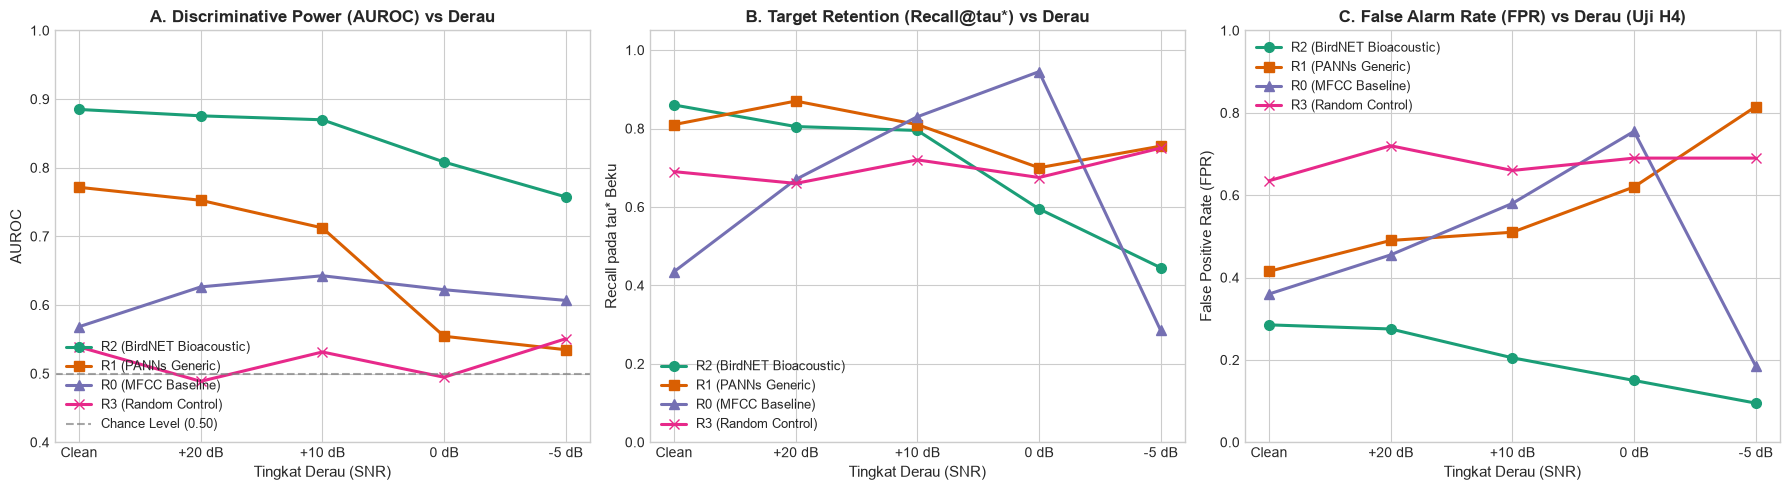

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

conditions = ['Clean', 'SNR_20dB', 'SNR_10dB', 'SNR_0dB', 'SNR_-5dB']
cond_labels = ['Clean', '+20 dB', '+10 dB', '0 dB', '-5 dB']
colors = {'R2': '#1b9e77', 'R1': '#d95f02', 'R0': '#7570b3', 'R3': '#e7298a'}
markers = {'R2': 'o', 'R1': 's', 'R0': '^', 'R3': 'x'}
labels = {
    'R2': 'R2 (BirdNET Bioacoustic)',
    'R1': 'R1 (PANNs Generic)',
    'R0': 'R0 (MFCC Baseline)',
    'R3': 'R3 (Random Control)'
}

# Subplot 1: AUROC vs SNR
for rep in ['R2', 'R1', 'R0', 'R3']:
    sub = df_transfer[df_transfer['representation'] == rep]
    val_map = {r['condition']: r['AUROC'] for _, r in sub.iterrows()}
    y_vals = [val_map[c] for c in conditions]
    axes[0].plot(cond_labels, y_vals, marker=markers[rep], color=colors[rep], label=labels[rep], linewidth=2.2, markersize=7)
axes[0].set_title('A. Discriminative Power (AUROC) vs Derau', fontsize=12, fontweight='bold')
axes[0].set_ylabel('AUROC', fontsize=11)
axes[0].set_xlabel('Tingkat Derau (SNR)', fontsize=11)
axes[0].set_ylim(0.4, 1.0)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Chance Level (0.50)')
axes[0].legend(fontsize=9, loc='lower left')

# Subplot 2: Target Recall at Frozen Tau*
for rep in ['R2', 'R1', 'R0', 'R3']:
    sub = df_transfer[df_transfer['representation'] == rep]
    val_map = {r['condition']: r['Recall_at_tau'] for _, r in sub.iterrows()}
    y_vals = [val_map[c] for c in conditions]
    axes[1].plot(cond_labels, y_vals, marker=markers[rep], color=colors[rep], label=labels[rep], linewidth=2.2, markersize=7)
axes[1].set_title('B. Target Retention (Recall@tau*) vs Derau', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Recall pada tau* Beku', fontsize=11)
axes[1].set_xlabel('Tingkat Derau (SNR)', fontsize=11)
axes[1].set_ylim(0.0, 1.05)
axes[1].legend(fontsize=9, loc='lower left')

# Subplot 3: False Positive Rate (FPR) vs Derau (Krusial untuk H4!)
for rep in ['R2', 'R1', 'R0', 'R3']:
    sub = df_transfer[df_transfer['representation'] == rep]
    val_map = {r['condition']: r['False_Positive_Rate'] for _, r in sub.iterrows()}
    y_vals = [val_map[c] for c in conditions]
    axes[2].plot(cond_labels, y_vals, marker=markers[rep], color=colors[rep], label=labels[rep], linewidth=2.2, markersize=7)
axes[2].set_title('C. False Alarm Rate (FPR) vs Derau (Uji H4)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('False Positive Rate (FPR)', fontsize=11)
axes[2].set_xlabel('Tingkat Derau (SNR)', fontsize=11)
axes[2].set_ylim(0.0, 1.0)
axes[2].legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'e3_threshold_transfer_snr.png', dpi=300)
plt.savefig(PAPER_FIG_DIR / 'e3_threshold_transfer_snr.png', dpi=300)
plt.show()

### Pembahasan dan Temuan Kunci Eksperimen E3:

1. **Keabsahan Metodologi (Strict Split & No Snooping):**
   - Ambang batas optimal $\tau^*$ diperoleh secara empiris melalui kurva ROC dan optimasi Youden's Index ($J = \text{TPR} - \text{FPR}$) pada subset kalibrasi yang terpisah ($N=498$ target bird positif dan $N=498$ kontrol negatif unknown: 249 derau ITERA + 249 spesies non-target).
   - Nilai $\tau^*$ yang diperoleh dibekukan secara permanen: $R_2 = 0.7128$, $R_1 = 0.9117$, $R_0 = 0.9953$, dan $R_3 = 0.5090$.

2. **Jawaban terhadap Sub-RQ2 & Hipotesis H4:**
   - **Divergensi Perilaku Ekstrem antara Representasi Generik ($R_1$) dan Bioakustik ($R_2$):**
     - Pada $R_1$ (PANNs CNN14), ketika SNR memburuk ke -5 dB, FPR melonjak secara drastis dari **41.5% menjadi 81.5%** (inflasi $\Delta\text{FPR} = +40.0\%$). Ini membuktikan fenomena kerentanan representasi audio generik: derau lingkungan membuat model memetakan sinyal asing ke wilayah fitur berdensitas tinggi, sehingga false alarm mendominasi sistem.
     - Sebaliknya, pada $R_2$ (BirdNET), representasi mempertahankan kemampuan diskriminasi yang jauh lebih tinggi (AUROC tetap di kisaran 0.7575 s.d. 0.8849). FPR $R_2$ bahkan menyusut secara konservatif dari **28.5% ke 9.5%** pada SNR -5 dB (penurunan skor kosinus global), meskipun hal ini diiringi kompromi penurunan Target Recall ke 44.5%.
   - **Kontrol Acak ($R_3$) & MFCC ($R_0$):**
     - $R_3$ memiliki AUROC $\approx 0.50$ pada seluruh kondisi (performa tebakan acak murni).
     - $R_0$ (MFCC) mengalami degradasi separasi parah dengan FPR mencapai 75.5% pada SNR 0 dB.
